In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from os import getenv
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, average_precision_score, precision_recall_curve
from sklearn.feature_extraction import DictVectorizer
from joblib import dump, load
from utils import calculate_indicators

В этом модуле мы обучим, протестируем и сохраним в отдельный фаил joblib модель машинного обучения

Получение и подготовка данных

In [4]:
# выгружаю токен для т-инвестиций
TOKEN = getenv("t_bank_token")

In [5]:
# заргружаем данные свечей из csv файла
df = pd.read_csv('2016-2025_candles_to_train.csv', index_col=[0], parse_dates=['date'])
# выводим первыe 5 строк
df.head(5)

,ticker,date,open,high,low,close,volume
0,ABIO,2018-03-07,10.30,10.30,9.10,9.70,10120
1,ABIO,2018-03-09,9.76,10.10,9.56,9.90,2240
2,ABIO,2018-03-12,9.80,10.10,9.76,9.96,1600
3,ABIO,2018-03-13,9.86,10.20,9.70,10.00,1150
4,ABIO,2018-03-14,10.06,10.16,9.90,10.00,1230


In [6]:
# копируем данные в новую переменную
candles = df.copy()

In [7]:
# проводим рассчёт дополнительных индикаторов
candles = calculate_indicators(df)

In [8]:

# Список всех индикаторов, которые нужно сдвинуть (чтобы не было утечки)
indicators_to_shift = [
        'atr', 'obv', 'stoch_k','stoch_d', 'volume_ratio', 'rsi', 'rsi_slope',
        'ema_12', 'ema_26', 'ema_slope', 'sma_10', 'sma_40', 'price_vs_sma_10',
        'sma10_vs_sma40', 'cci_20', 'macd', 'signal', 'hist', 'hist_slope',
        'williams_r', 'volatility_20', 'volatility_60', 'vol_ratio_20_60',
        'momentum', 'range_ratio','range_norm' ,'volume_spike', 'ad_line', 'return', 'open_close_ratio'
        ]

# Сдвигаем все индикаторы на 1 бар вперед (shift(1))
# Теперь значение в строке N — это значение индикатора, рассчитанное на данных строки N-1
candles[indicators_to_shift] = candles[indicators_to_shift].shift(1)

In [9]:
# удаляем бесконечности и NaN
candles.replace([np.inf, -np.inf], np.nan, inplace=True)
candles.dropna(inplace=True)

In [10]:
# смотрим на обновленные данные
candles.head(5)

,ticker,date,open,high,low,close,volume,atr,obv,stoch_k,...,vol_ratio_20_60,momentum,range_norm,range_ratio,open_close_ratio,volume_spike,ad_line,return,return_7d,target
70,ABIO,2018-06-19,9.16,9.16,9.16,9.16,50,0.326992,-34200.0,39.755273,...,0.720048,0.989011,0.100000,1.044643,1.022222,1.0,-19464.268771,-0.021739,0.037118,1
71,ABIO,2018-06-20,9.00,9.20,8.96,9.06,20180,0.319040,-34150.0,39.605528,...,0.753210,0.989201,0.000000,1.000000,1.000000,0.0,-19464.268771,0.017778,0.092715,1
72,ABIO,2018-06-21,9.20,9.56,9.16,9.56,8140,0.315276,-54330.0,38.108073,...,0.749608,0.995604,0.416667,1.026786,0.993377,1.0,-22827.602104,-0.010917,-0.006276,0
73,ABIO,2018-06-22,9.00,9.60,9.00,9.56,3920,0.324073,-46190.0,45.163223,...,0.914964,1.039130,1.000000,1.043668,0.962343,0.0,-14687.602104,0.055188,0.077406,1
74,ABIO,2018-06-25,9.60,10.10,9.60,10.06,4910,0.337212,-46190.0,51.611635,...,0.924314,1.062222,0.933333,1.066667,0.941423,0.0,-11290.268771,0.000000,0.029821,1


Разбивка временных рядов, обучение и тест

In [11]:
# получаем индекс разделяющий данные 80% на 20%
index = int(len(candles.date) * 0.8)
# получаем дату находящуюся в этом индексе
date_to_train = candles.date.iloc[index]
date_to_train

Timestamp('2023-09-25 00:00:00')

In [12]:
# разделяем данные на обучающие и тестовые
train = candles[candles.date < date_to_train]
test = candles[candles.date >= date_to_train]

In [13]:
# в этих переменных хранится то, что мы будем стараться предсказать
y_train = train.target.values
y_test = test.target.values

In [14]:
# убираем колонки, которые нельзя использовать в обучении
features_col = [col for col in candles.columns if col not in ['index', 'open', 'high', 'low', 'close', 'volume','date', 'target', 'return_7d']]
# смотрим на результат
features_col

['ticker',
 'atr',
 'obv',
 'stoch_k',
 'stoch_d',
 'volume_ratio',
 'rsi',
 'rsi_slope',
 'ema_12',
 'ema_26',
 'ema_slope',
 'sma_10',
 'sma_40',
 'price_vs_sma_10',
 'sma10_vs_sma40',
 'cci_20',
 'macd',
 'signal',
 'hist',
 'hist_slope',
 'williams_r',
 'volatility_20',
 'volatility_60',
 'vol_ratio_20_60',
 'momentum',
 'range_norm',
 'range_ratio',
 'open_close_ratio',
 'volume_spike',
 'ad_line',
 'return']

In [15]:
# подключаем DictVectorier для создания матрицы данных
dv = DictVectorizer(sparse=False)
# преобразуем данные в словари
train_dict = train[features_col].to_dict(orient='records')
test_dict = test[features_col].to_dict(orient='records')
# обучаем векторайзер
dv.fit(train_dict)

,dtype,<class 'numpy.float64'>
,separator,'='
,sparse,False
,sort,True


In [16]:
# при помощи векторайзера создаём матрицы для машинного обучения
X_train = dv.transform(train_dict)
X_test = dv.transform(test_dict)

In [17]:
# подключаем класификатор случайного леса для машинного обучения
RFС_model = RandomForestClassifier(n_estimators=200, max_depth=30, min_samples_split=10, min_samples_leaf=40, max_features='log2', class_weight='balanced', n_jobs=-1)
# обучаем модель
RFС_model.fit(X_train, y_train)
# получаем предсказания для тестовой выборки
y_proba = RFС_model.predict_proba(X_test)[:,1]
# оцениваем качество модели
AP = ap = round(average_precision_score(y_test, y_proba),3)
print('AP = ', AP)

AP =  0.439


In [18]:
# идея этого кода найти подходящий порог вероятности, после которого можно считать предсказание истинным
# в это переменной хранятся пороги вероятности от 0.5 до 0.99
thresholds = np.arange(.5,.99, .01).round(2)

# проходимся по каждому порогу и считаем точность
for t in thresholds:
    y_pred_labels = (y_proba > t).astype(int)
    n_signals = y_pred_labels.sum()

    # Защита от деления на ноль, если сигналов нет
    if n_signals == 0:
        prec = 0.0
    else:
        prec = precision_score(y_test, y_pred_labels)


    print(f"threshold: {t}, precision: {prec:.3}, signals: {n_signals}")

threshold: 0.5, precision: 0.413, signals: 58941
threshold: 0.51, precision: 0.418, signals: 50546
threshold: 0.52, precision: 0.425, signals: 41804
threshold: 0.53, precision: 0.433, signals: 33045
threshold: 0.54, precision: 0.446, signals: 24859
threshold: 0.55, precision: 0.458, signals: 17466
threshold: 0.56, precision: 0.467, signals: 11797
threshold: 0.57, precision: 0.487, signals: 7602
threshold: 0.58, precision: 0.511, signals: 4778
threshold: 0.59, precision: 0.53, signals: 2964
threshold: 0.6, precision: 0.552, signals: 1863
threshold: 0.61, precision: 0.575, signals: 1216
threshold: 0.62, precision: 0.58, signals: 754
threshold: 0.63, precision: 0.574, signals: 472
threshold: 0.64, precision: 0.587, signals: 254
threshold: 0.65, precision: 0.606, signals: 132
threshold: 0.66, precision: 0.582, signals: 67
threshold: 0.67, precision: 0.562, signals: 32
threshold: 0.68, precision: 0.579, signals: 19
threshold: 0.69, precision: 0.667, signals: 9
threshold: 0.7, precision: 0.5

In [19]:
# в этой ячейке пытаемся посчитать доходность и визуально оценить качество предсказания
# также перебираем пороги для определения оптимального значения
for t in np.arange(.65, .91, 0.01):
    y_pred_labels = (y_proba > t).astype(int)
    # комиссия за покупку и продажу
    commission_cost = 0.003 * 2
    # получаем доходность для тех прогноов, где модель порекомендовала покупать
    signal_returns = test['return_7d'].values[y_pred_labels == 1]

    if len(signal_returns) > 0:
        # считываем среднюю дохоность
        mean_ret = signal_returns.mean()
        # считаем какая доля была угадана
        win_rate = (signal_returns > 0).mean()
        # итоговая доходность после комиссии
        net_return = mean_ret - commission_cost

        print(f"Порог: {t:.2}, средняя доходность с учетом комиссии: {(net_return * 100):.3} %, количество сигналов: {len(signal_returns)}")

Порог: 0.65, средняя доходность с учетом комиссии: 4.47 %, количество сигналов: 132
Порог: 0.66, средняя доходность с учетом комиссии: 4.95 %, количество сигналов: 67
Порог: 0.67, средняя доходность с учетом комиссии: 5.11 %, количество сигналов: 32
Порог: 0.68, средняя доходность с учетом комиссии: 4.34 %, количество сигналов: 19
Порог: 0.69, средняя доходность с учетом комиссии: 7.41 %, количество сигналов: 9
Порог: 0.7, средняя доходность с учетом комиссии: 2.39 %, количество сигналов: 4
Порог: 0.71, средняя доходность с учетом комиссии: 5.04 %, количество сигналов: 2
Порог: 0.72, средняя доходность с учетом комиссии: -3.29 %, количество сигналов: 1
Порог: 0.73, средняя доходность с учетом комиссии: -3.29 %, количество сигналов: 1


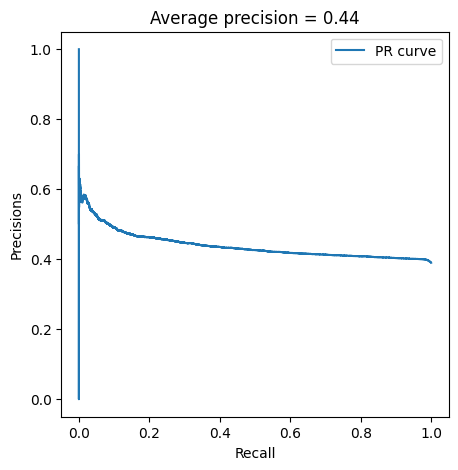

In [20]:
# рисуем график
prec, rec, thresh = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(5,5))
plt.title(f'Average precision = {AP:.2}')
plt.xlabel('Recall')
plt.ylabel('Precisions')
plt.plot(rec, prec, label='PR curve')
plt.legend()
plt.show()

Переобучим модель на всех имеющихся данных и сохраняем ее

In [21]:
# в этой ячейке мы делаем то, что уже проделывали ранее
train = candles.copy()
y_train = train.target.values
train_dict = train[features_col].to_dict(orient="records")
X_train = dv.fit_transform(train_dict)

model = RandomForestClassifier(n_estimators=200, max_depth=30, min_samples_split=10, min_samples_leaf=40, max_features='log2', class_weight='balanced', n_jobs=-1)
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,30
,min_samples_split,10
,min_samples_leaf,40
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
# сохраняем тикеры в переменную
ticker_list = candles.ticker.unique().tolist()
# выгружаем тикеры, векторайзер и модель в оидельный файл
dump((ticker_list ,dv, model), 'stocks_analyser_tickers_dv_with_model.joblib')

['stocks_analyser_tickers_dv_with_model.joblib']

Протестируем данные на отдельном файле со свежими данными

In [23]:
test_df = pd.read_csv('candles_to_validation.csv', index_col=0, parse_dates=['date']).sort_values(['ticker', 'date'])

In [24]:
test_df = calculate_indicators(test_df)

In [25]:
indicators_to_shift = [
        'atr', 'obv', 'stoch_k','stoch_d', 'volume_ratio', 'rsi', 'rsi_slope',
        'ema_12', 'ema_26', 'ema_slope', 'sma_10', 'sma_40', 'price_vs_sma_10',
        'sma10_vs_sma40', 'cci_20', 'macd', 'signal', 'hist', 'hist_slope',
        'williams_r', 'volatility_20', 'volatility_60', 'vol_ratio_20_60',
        'momentum', 'range_ratio','range_norm' ,'volume_spike', 'ad_line', 'return', 'open_close_ratio'
        ]

test_df[indicators_to_shift] = test_df[indicators_to_shift].shift(1)

In [26]:
test_df.replace([np.inf, -np.inf], np.nan, inplace=True)
test_df.dropna(inplace=True)

In [63]:
# проводим ручную фильтрацию по техническим индиакторам для тестовой выборки
new_df = test_df[
    (test_df.sma10_vs_sma40 > 1.02) &
    (test_df['hist'] > test_df.signal) &
    (test_df.stoch_k > test_df.stoch_d) &
    (test_df['volume_ratio'] > 1.2) &
    (test_df['volume_spike'] == 1) &
    (test_df['ema_12'] > test_df['ema_26']) &
    (test_df['price_vs_sma_10'] > 1.01)
    ]

In [64]:
tickers ,dv, model = load('stocks_analyser_tickers_dv_with_model.joblib')

In [65]:
# проводим анализ данных на 10 случайных датах
t = 0.6

for date in np.random.choice(new_df.date, size=10, replace=False):
    print(str(date)[:10])
    res_df = test_df[test_df.date == date]
    X = dv.transform(res_df[features_col].to_dict(orient="records"))
    pred = model.predict_proba(X)


    y = (pred > t).astype(int)
    commission_cost = 0.003 * 2
    signal_returns = res_df.loc[y == 1, 'return_7d'].values

    if len(signal_returns) > 0:
        mean_ret = signal_returns.mean()
        win_rate = (signal_returns > 0).mean()
        net_return = mean_ret - commission_cost

        print(f"Порог: {t:.2}, средняя доходность с учетом комиссии: {(net_return * 100):.5} %, количество сигналов: {len(signal_returns)}, точность: {win_rate:.2}")


2026-01-13
Порог: 0.6, средняя доходность с учетом комиссии: 1.2323 %, количество сигналов: 4, точность: 0.5
2026-01-12
Порог: 0.6, средняя доходность с учетом комиссии: 1.8395 %, количество сигналов: 22, точность: 0.86
2026-01-16
Порог: 0.6, средняя доходность с учетом комиссии: 1.4047 %, количество сигналов: 3, точность: 0.33
2026-01-13
Порог: 0.6, средняя доходность с учетом комиссии: 1.2323 %, количество сигналов: 4, точность: 0.5
2026-01-15
Порог: 0.6, средняя доходность с учетом комиссии: 1.9081 %, количество сигналов: 4, точность: 0.5
2026-01-09
Порог: 0.6, средняя доходность с учетом комиссии: 2.0971 %, количество сигналов: 19, точность: 0.68
2026-01-14
Порог: 0.6, средняя доходность с учетом комиссии: 1.6072 %, количество сигналов: 3, точность: 0.67
2026-01-09
Порог: 0.6, средняя доходность с учетом комиссии: 2.0971 %, количество сигналов: 19, точность: 0.68
2026-01-12
Порог: 0.6, средняя доходность с учетом комиссии: 1.8395 %, количество сигналов: 22, точность: 0.86
2026-04-2

In [66]:
pred = model.predict_proba(dv.transform(test_df[features_col].to_dict(orient='records')))[:, 1]
AP = average_precision_score(test_df.target, (pred > t).astype(int))
print('AP = ', AP)

AP =  0.3187965496982634


In [67]:
pred_ta = model.predict_proba(dv.transform(new_df[features_col].to_dict(orient='records')))[:, 1]
AP_TA = average_precision_score(new_df.target, (pred_ta > t).astype(int))
print('AP = ', AP_TA)

AP =  0.6404109589041096


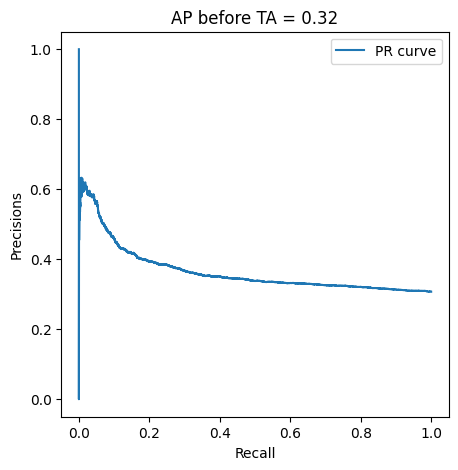

In [68]:
prec, rec, thresh = precision_recall_curve(test_df.target, pred)

plt.figure(figsize=(5,5))
plt.title(f'AP before TA = {AP:.2}')
plt.xlabel('Recall')
plt.ylabel('Precisions')
plt.plot(rec, prec, label='PR curve')
plt.legend()
plt.show()

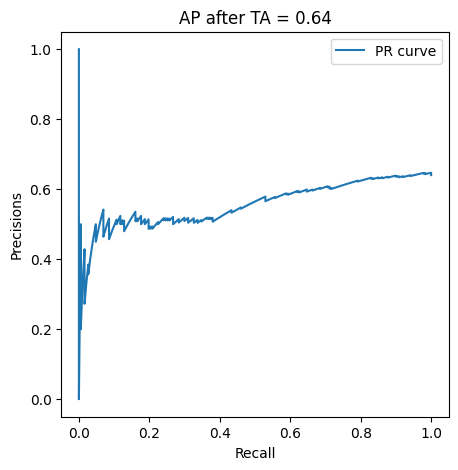

In [69]:
prec, rec, thresh = precision_recall_curve(new_df.target, pred_ta)

plt.figure(figsize=(5,5))
plt.title(f'AP after TA = {AP_TA:.2}')
plt.xlabel('Recall')
plt.ylabel('Precisions')
plt.plot(rec, prec, label='PR curve')
plt.legend()
plt.show()